#### Import libraries and load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

c:\Users\makge\anaconda33\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\makge\anaconda33\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
housing_df = pd.read_csv('./housing.csv')
housing_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
housing_df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [5]:
housing_df_shuffled = housing_df.sample(n=len(housing_df),random_state=1)
housing_df_shuffled

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
4712,-118.36,34.06,39.0,2810.0,670.0,1109.0,624.0,3.2500,355000.0,<1H OCEAN
2151,-119.78,36.78,37.0,2185.0,455.0,1143.0,438.0,1.9784,70700.0,INLAND
15927,-122.42,37.73,46.0,1819.0,411.0,1534.0,406.0,4.0132,229400.0,NEAR BAY
82,-122.28,37.81,52.0,340.0,97.0,200.0,87.0,1.5208,112500.0,NEAR BAY
8161,-118.13,33.82,37.0,1530.0,290.0,711.0,283.0,5.1795,225400.0,<1H OCEAN
...,...,...,...,...,...,...,...,...,...,...
10955,-117.88,33.76,17.0,1768.0,474.0,1079.0,436.0,1.7823,205300.0,<1H OCEAN
17289,-119.63,34.42,42.0,1765.0,263.0,753.0,260.0,8.5608,500001.0,<1H OCEAN
5192,-118.26,33.93,42.0,1433.0,295.0,775.0,293.0,1.1326,104800.0,<1H OCEAN
12172,-117.16,33.73,10.0,2381.0,454.0,1323.0,477.0,2.6322,140700.0,INLAND


In [8]:
pd.get_dummies(housing_df_shuffled['ocean_proximity'],dtype=int).head()

,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
4712,1,0,0,0,0
2151,0,1,0,0,0
15927,0,0,0,1,0
82,0,0,0,1,0
8161,1,0,0,0,0


In [16]:
housing_df_final = pd.concat([(housing_df_shuffled.drop('ocean_proximity',axis=1)),
                              (pd.get_dummies(housing_df_shuffled['ocean_proximity'],dtype=int))],axis=1)

housing_df_final

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
4712,-118.36,34.06,39.0,2810.0,670.0,1109.0,624.0,3.2500,355000.0,1,0,0,0,0
2151,-119.78,36.78,37.0,2185.0,455.0,1143.0,438.0,1.9784,70700.0,0,1,0,0,0
15927,-122.42,37.73,46.0,1819.0,411.0,1534.0,406.0,4.0132,229400.0,0,0,0,1,0
82,-122.28,37.81,52.0,340.0,97.0,200.0,87.0,1.5208,112500.0,0,0,0,1,0
8161,-118.13,33.82,37.0,1530.0,290.0,711.0,283.0,5.1795,225400.0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10955,-117.88,33.76,17.0,1768.0,474.0,1079.0,436.0,1.7823,205300.0,1,0,0,0,0
17289,-119.63,34.42,42.0,1765.0,263.0,753.0,260.0,8.5608,500001.0,1,0,0,0,0
5192,-118.26,33.93,42.0,1433.0,295.0,775.0,293.0,1.1326,104800.0,1,0,0,0,0
12172,-117.16,33.73,10.0,2381.0,454.0,1323.0,477.0,2.6322,140700.0,0,1,0,0,0


In [10]:
housing_df_final.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', '<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY',
       'NEAR OCEAN'],
      dtype='str')

In [15]:
housing_df_final

[['longitude',
  'latitude',
  'housing_median_age',
  'total_rooms',
  'total_bedrooms',
  'population',
  'households',
  'median_income',
  '<1H OCEAN',
  'INLAND',
  'ISLAND',
  'NEAR BAY',
  'NEAR OCEAN',
  'median_house_value']]

In [17]:
housing_df_final = housing_df_final[['longitude', 'latitude', 
                                     'housing_median_age', 'total_rooms',
                                    'total_bedrooms', 'population', 'households', 
                                    'median_income', '<1H OCEAN', 'INLAND', 'ISLAND',
                                    'NEAR BAY','NEAR OCEAN','median_house_value']]

housing_df_final

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,median_house_value
4712,-118.36,34.06,39.0,2810.0,670.0,1109.0,624.0,3.2500,1,0,0,0,0,355000.0
2151,-119.78,36.78,37.0,2185.0,455.0,1143.0,438.0,1.9784,0,1,0,0,0,70700.0
15927,-122.42,37.73,46.0,1819.0,411.0,1534.0,406.0,4.0132,0,0,0,1,0,229400.0
82,-122.28,37.81,52.0,340.0,97.0,200.0,87.0,1.5208,0,0,0,1,0,112500.0
8161,-118.13,33.82,37.0,1530.0,290.0,711.0,283.0,5.1795,1,0,0,0,0,225400.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10955,-117.88,33.76,17.0,1768.0,474.0,1079.0,436.0,1.7823,1,0,0,0,0,205300.0
17289,-119.63,34.42,42.0,1765.0,263.0,753.0,260.0,8.5608,1,0,0,0,0,500001.0
5192,-118.26,33.93,42.0,1433.0,295.0,775.0,293.0,1.1326,1,0,0,0,0,104800.0
12172,-117.16,33.73,10.0,2381.0,454.0,1323.0,477.0,2.6322,0,1,0,0,0,140700.0


**Null rows**

In [19]:
housing_df_final.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
<1H OCEAN               0
INLAND                  0
ISLAND                  0
NEAR BAY                0
NEAR OCEAN              0
median_house_value      0
dtype: int64

In [20]:
housing_df_final = housing_df_final.dropna()

In [21]:
housing_df_final.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
<1H OCEAN             0
INLAND                0
ISLAND                0
NEAR BAY              0
NEAR OCEAN            0
median_house_value    0
dtype: int64

**Split the dataset into Train, Test, and Validation**

In [22]:
len(housing_df_final)

20433

In [24]:
train_df,test_df,val_df = housing_df_final[:18000],housing_df_final[18000:19217],housing_df_final[19215:]
len(train_df),len(test_df),len(val_df)

(18000, 1217, 1218)

In [25]:
train_df.shape

(18000, 14)

In [29]:
X_train, y_train = train_df.to_numpy()[:,:-1],train_df.to_numpy()[:,-1]
X_val,y_val = val_df.to_numpy()[:,:-1],val_df.to_numpy()[:,-1]
X_test, y_test = test_df.to_numpy()[:,:-1],test_df.to_numpy()[:,-1]

In [31]:
X_train.shape,y_train.shape,X_val.shape,y_val.shape,X_test.shape, y_test.shape

((18000, 13), (18000,), (1218, 13), (1218,), (1217, 13), (1217,))

**Preprocessing**

In [32]:
from sklearn.preprocessing import StandardScaler

In [33]:
scaler = StandardScaler().fit(X_train[:,:8])

def preprocessor(X):
    A = np.copy(X)
    A[:,:8] = scaler.transform(A[:,:8])
    return A

X_train_preprocessed = preprocessor(X_train)
X_train_preprocessed

array([[ 0.60344338, -0.73607301,  0.82084451, ...,  0.        ,
         0.        ,  0.        ],
       [-0.10512186,  0.53710782,  0.66177382, ...,  0.        ,
         0.        ,  0.        ],
       [-1.42245442,  0.98178495,  1.37759191, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 0.59346359, -0.7313922 , -0.61079167, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.12738246, -0.7313922 ,  0.90037985, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.92279673, -0.94202873, -0.61079167, ...,  0.        ,
         0.        ,  0.        ]])

In [34]:
pd.DataFrame(X_train_preprocessed)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.603443,-0.736073,0.820845,0.081039,0.315396,-0.276840,0.328234,-0.326667,1.0,0.0,0.0,0.0,0.0
1,-0.105122,0.537108,0.661774,-0.206526,-0.196843,-0.246809,-0.160526,-0.995001,0.0,1.0,0.0,0.0,0.0
2,-1.422454,0.981785,1.377592,-0.374924,-0.301674,0.098553,-0.244613,0.074459,0.0,0.0,0.0,1.0,0.0
3,-1.352596,1.019231,1.854804,-1.055419,-1.049782,-1.079740,-1.082862,-1.235508,0.0,0.0,0.0,1.0,0.0
4,0.718211,-0.848412,0.661774,-0.507894,-0.589957,-0.628385,-0.567825,0.687448,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17995,0.728191,-0.815647,0.423168,-0.057912,0.134325,0.111802,0.120643,-0.349320,1.0,0.0,0.0,0.0,0.0
17996,-0.459404,0.785191,1.298057,-0.368023,-0.277849,-0.015390,-0.241986,-0.956265,0.0,1.0,0.0,0.0,0.0
17997,0.593464,-0.731392,-0.610792,0.468908,0.996794,0.077354,1.027213,-0.165155,1.0,0.0,0.0,0.0,0.0
17998,1.127382,-0.731392,0.900380,0.139013,0.463112,0.531359,0.464877,-0.923784,0.0,1.0,0.0,0.0,0.0


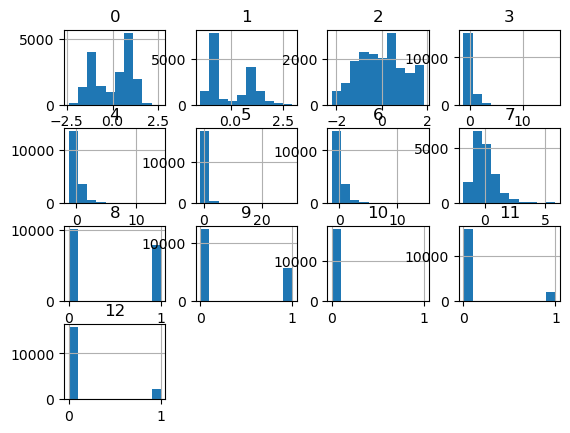

In [38]:

pd.DataFrame(X_train_preprocessed).hist()
plt.show()

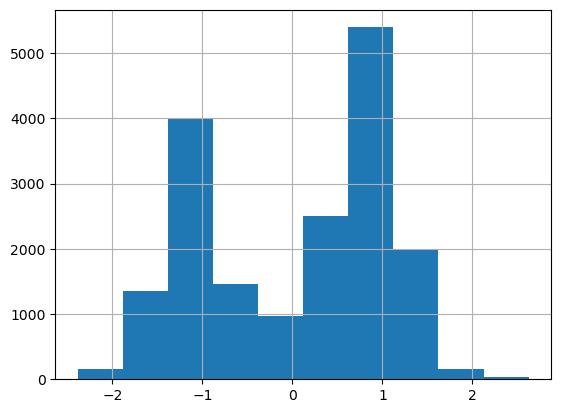

In [40]:
pd.DataFrame(X_train_preprocessed)[0].hist()
plt.show()

In [41]:
X_train,X_val,X_test = preprocessor(X_train),preprocessor(X_val),preprocessor(X_test)

In [42]:
X_train.shape,X_val.shape,X_test.shape

((18000, 13), (1218, 13), (1217, 13))

**Model**

In [43]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

**Linear Model**

In [45]:
lm = LinearRegression()
lm.fit(X_train,y_train)
mse = mean_squared_error(lm.predict(X_train),y_train)
print('Mean Squared error: ',mse)
rmse = mean_squared_error(lm.predict(X_train),y_train,squared=False)
print('Root mean squared error:',rmse)

Mean Squared error:  4705007301.412742
Root mean squared error: 68593.05578127236


In [46]:
lm = LinearRegression()
lm.fit(X_train,y_train)
mse = mean_squared_error(lm.predict(X_val),y_val)
print('Mean Squared error: ',mse)
rmse = mean_squared_error(lm.predict(X_val),y_val,squared=False)
print('Root mean squared error:',rmse)

Mean Squared error:  5095452109.80421
Root mean squared error: 71382.43558330165


**KNeighborsRegressor**

In [47]:
from sklearn.neighbors import KNeighborsRegressor

In [56]:
knn = KNeighborsRegressor(n_neighbors=15)
knn.fit(X_train,y_train)
mse = mean_squared_error(knn.predict(X_train),y_train,squared=False)
print('Root Mean Squared error: ',mse)
rmse = mean_squared_error(knn.predict(X_val),y_val,squared=False)
print('Root mean squared error:',rmse)


Root Mean Squared error:  55797.60309166373
Root mean squared error: 62069.66323809072


**Random forest**

In [50]:
from sklearn.ensemble import RandomForestRegressor


In [59]:
rfr = RandomForestRegressor(max_depth=10)
rfr.fit(X_train,y_train)
mse = mean_squared_error(rfr.predict(X_train),y_train,squared=False)
print('Root Mean Squared error: ',mse)
rmse = mean_squared_error(rfr.predict(X_val),y_val,squared=False)
print('Root mean squared error:',rmse)


Root Mean Squared error:  43425.787902666
Root mean squared error: 53488.09275526526


**Gradient Boosting**

In [60]:
from sklearn.ensemble import GradientBoostingRegressor

In [63]:
gbr = RandomForestRegressor(n_estimators=250)
gbr.fit(X_train,y_train)
mse = mean_squared_error(gbr.predict(X_train),y_train,squared=False)
print('Root Mean Squared error: ',mse)
rmse = mean_squared_error(gbr.predict(X_val),y_val,squared=False)
print('Root mean squared error:',rmse)


Root Mean Squared error:  17817.643350564384
Root mean squared error: 49293.149419632384


**Tensorflow**

In [ ]:
from